# Actividad 1: Decision Tree Classification Model

In [42]:
from pathlib import Path
import pandas as pd

# Importar dataset
DATA_PATH = Path.cwd() / "seattle-weather-dataset.csv"

data = pd.read_csv(DATA_PATH)
df = pd.DataFrame(data)

print("Sample data:")
df.head(5)

Sample data:


,date,precipitation,temp_max,temp_min,wind,weather
0,1/1/2012,0.0,12.8,5.0,4.7,drizzle
1,1/2/2012,10.9,10.6,2.8,4.5,rain
2,1/3/2012,0.8,11.7,7.2,2.3,rain
3,1/4/2012,20.3,12.2,5.6,4.7,rain
4,1/5/2012,1.3,8.9,2.8,6.1,rain


Modificar el dataset para ignorar la columna de fecha, pues no será necesaria para este ejercicio.

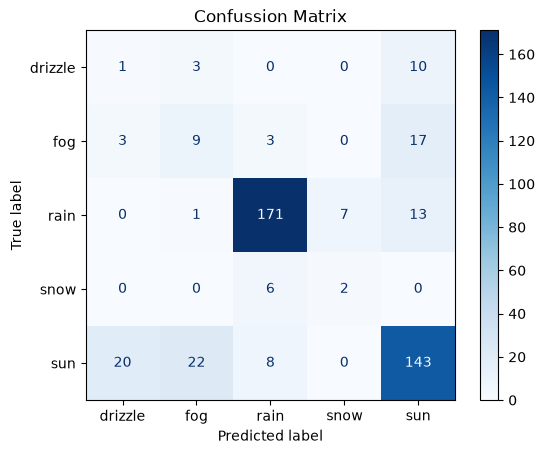

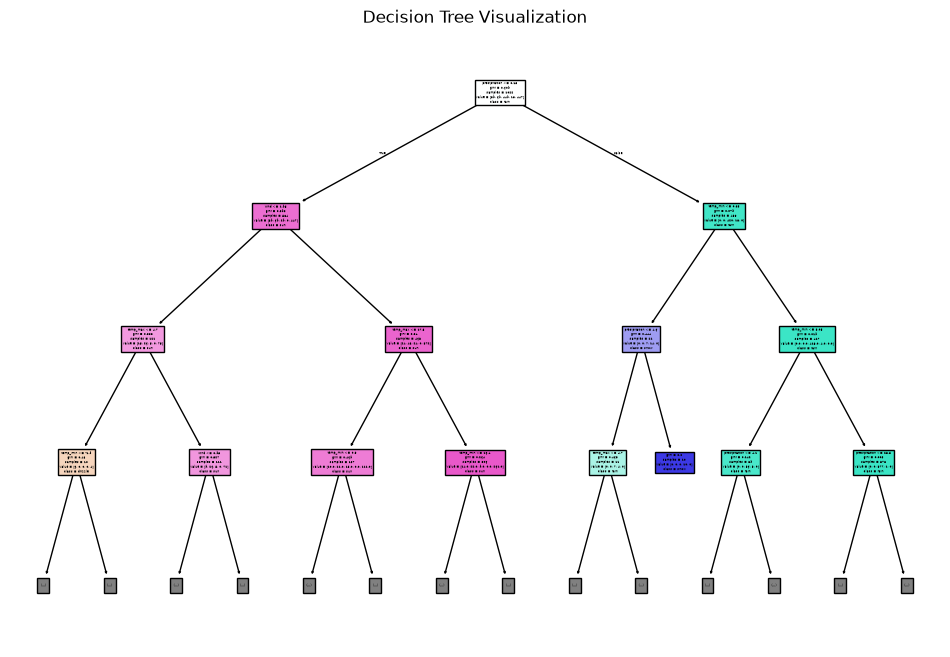

KeyError: 'Importance'

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Ignorar la variable de fecha
df_encoded = df.copy()
df_encoded = df_encoded.drop(columns=["date"]) # Dropping date variable

num_cols = df.select_dtypes(include='number').columns # Selecciona los nombres de las columnas numéricas

# Fijar objetivos del análisis
X = df_encoded[num_cols].copy()
y = df_encoded["weather"].copy()

# Entrenamiento del modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)
y_pred = dtree.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=dtree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confussion Matrix")
plt.show()
plt.figure(figsize=(12, 8))

# Árbol de decisiones
plot_tree(dtree, feature_names=X.columns, class_names=dtree.classes_, filled=True, max_depth=3)
plt.title("Decision Tree Visualization")
plt.show()

feature_importance = pd.DataFrame({'Feature': X.columns, "Importance": dtree.feature_importances_}) # Create a DataFrame containing each predictor and its in
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance)
plt.figure(figsize=(8,5))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.show()
